In [1]:
pip install opencv-python matplotlib "numpy<2"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:



import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

Matplotlib is building the font cache; this may take a moment.


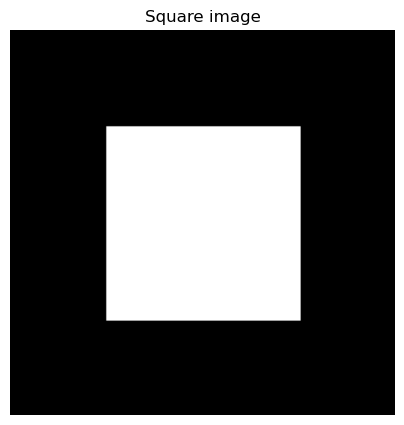

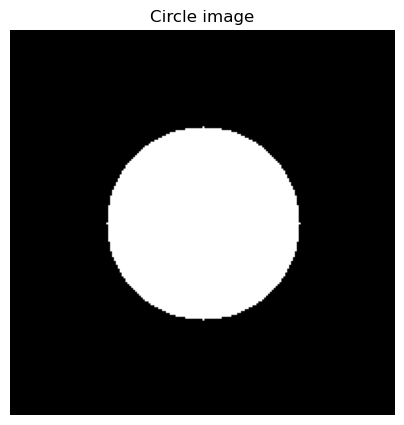

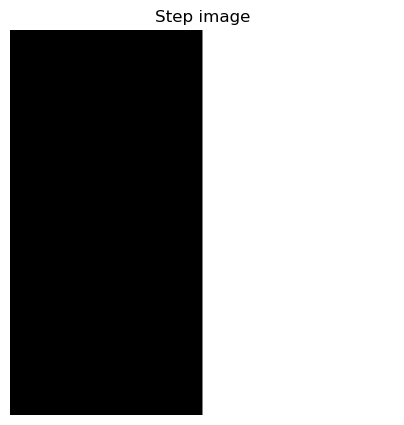

In [3]:
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

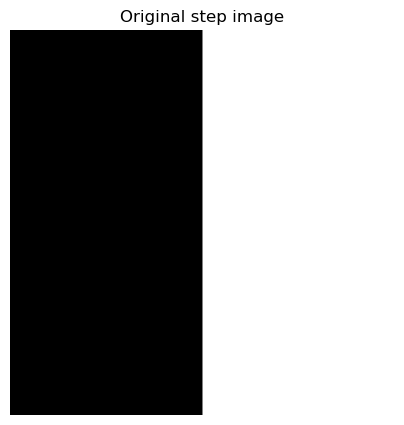

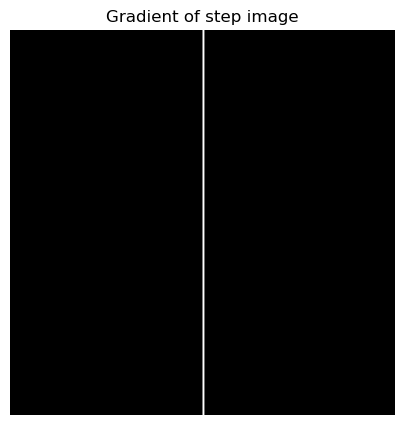

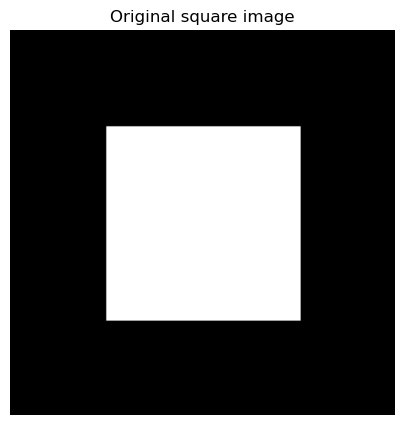

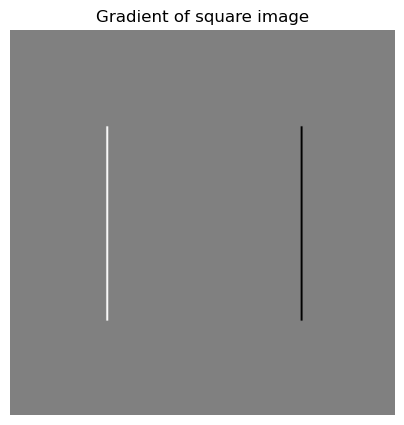

In [4]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

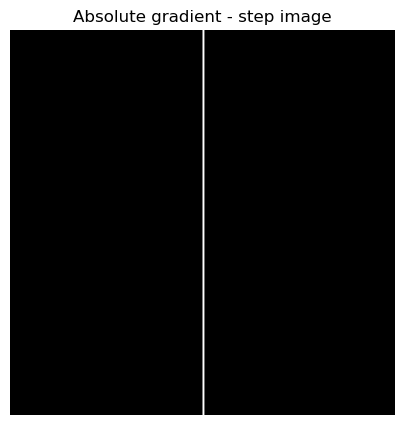

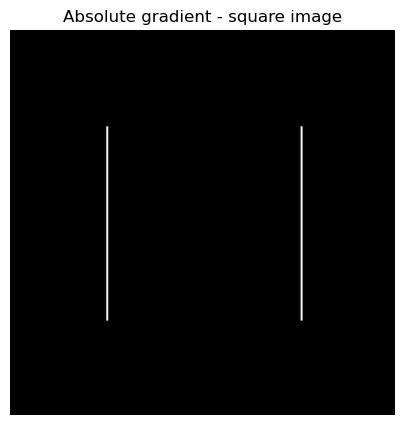

In [5]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

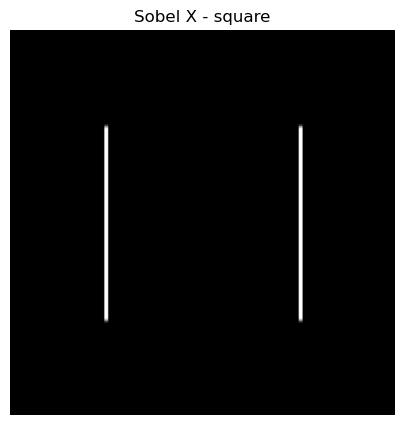

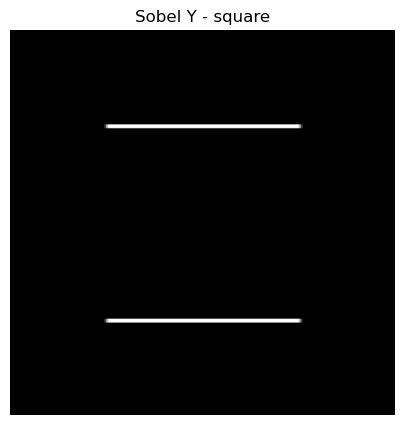

In [6]:
# Sobel in x and y directions
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")

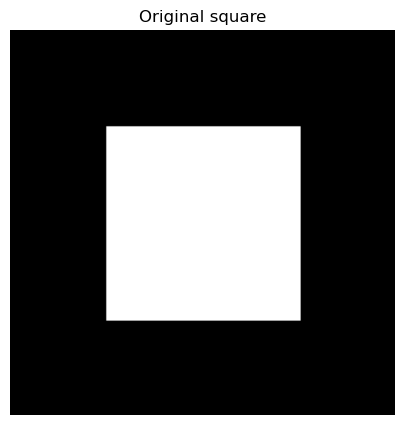

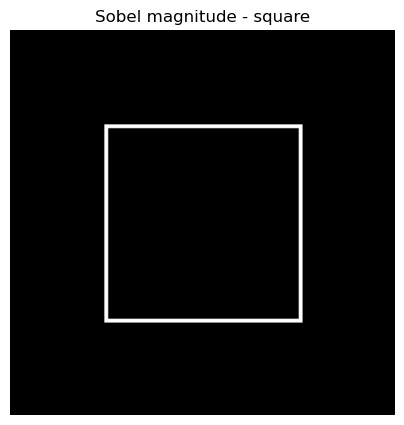

In [7]:
# Gradient magnitude from Sobel x and y
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

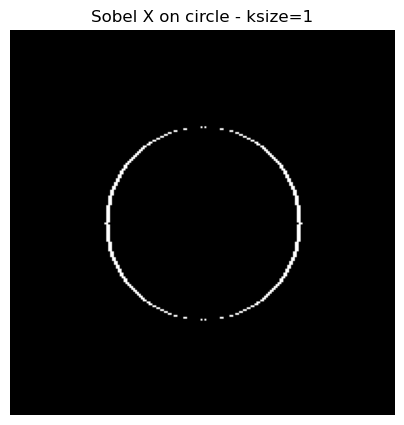

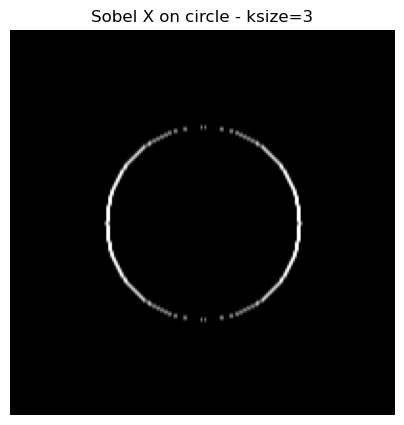

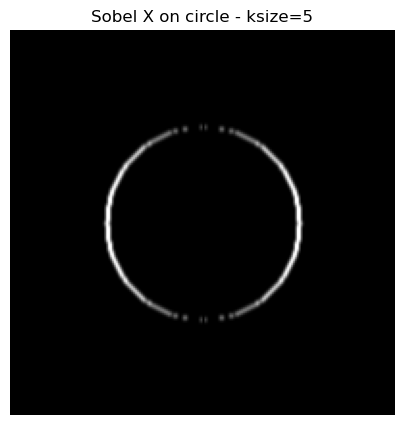

In [8]:
# Compare Sobel with different kernel sizes
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k), f"Sobel X on circle - ksize={k}")

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6,6)

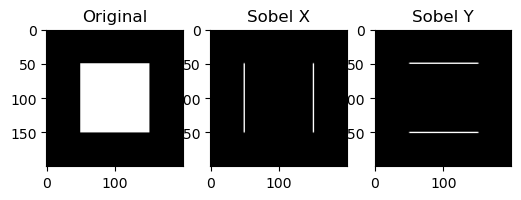

In [22]:
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

plt.subplot(131)
plt.title("Original")
plt.imshow(img_square, cmap="gray")

plt.subplot(132)
plt.title("Sobel X")
plt.imshow(np.abs(sobel_x), cmap="gray")

plt.subplot(133)
plt.title("Sobel Y")
plt.imshow(np.abs(sobel_y), cmap="gray")

plt.show()

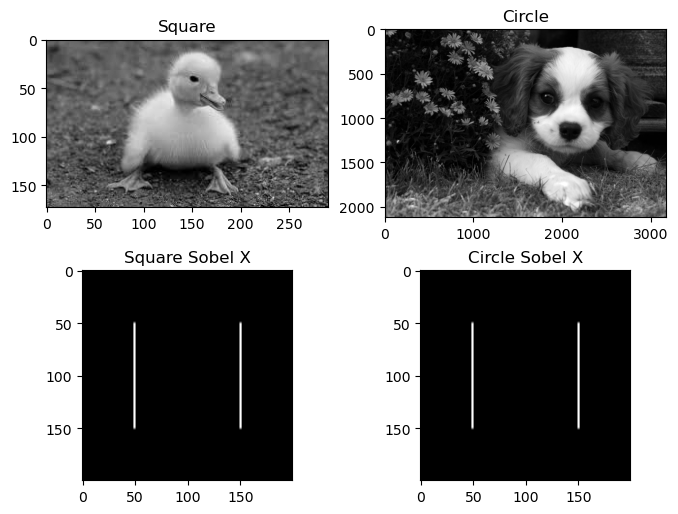

In [23]:
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

sx = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

plt.figure(figsize=(8,6))

plt.subplot(221)
plt.title("Square")
plt.imshow(square, cmap="gray")

plt.subplot(222)
plt.title("Circle")
plt.imshow(circle, cmap="gray")

plt.subplot(223)
plt.title("Square Sobel X")
plt.imshow(np.abs(sx), cmap="gray")

plt.subplot(224)
plt.title("Circle Sobel X")
plt.imshow(np.abs(sobel_x), cmap="gray")

plt.show()

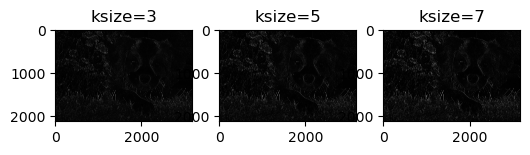

In [24]:
sobel3 = cv2.Sobel(circle, cv2.CV_64F, 1, 0, ksize=3)
sobel5 = cv2.Sobel(circle, cv2.CV_64F, 1, 0, ksize=5)
sobel7 = cv2.Sobel(circle, cv2.CV_64F, 1, 0, ksize=7)

plt.subplot(131)
plt.title("ksize=3")
plt.imshow(np.abs(sobel3), cmap="gray")

plt.subplot(132)
plt.title("ksize=5")
plt.imshow(np.abs(sobel5), cmap="gray")

plt.subplot(133)
plt.title("ksize=7")
plt.imshow(np.abs(sobel7), cmap="gray")

plt.show()

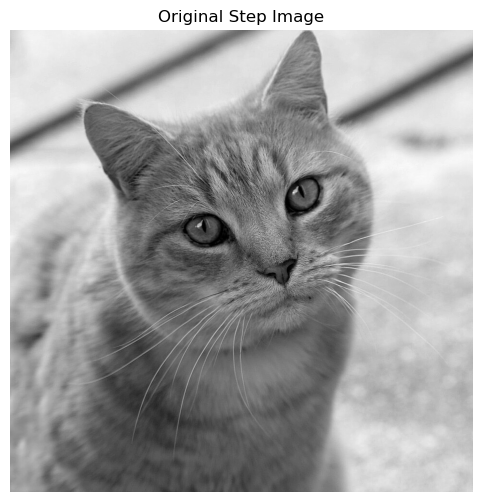

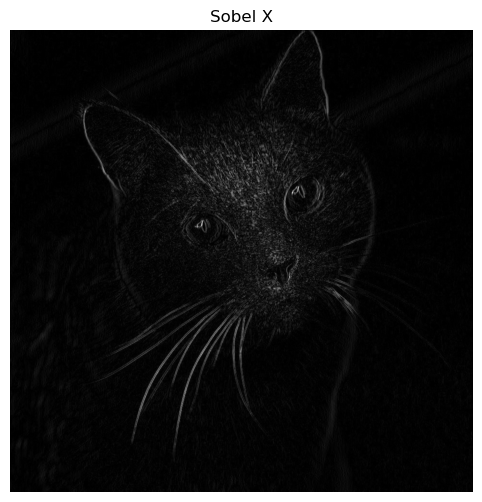

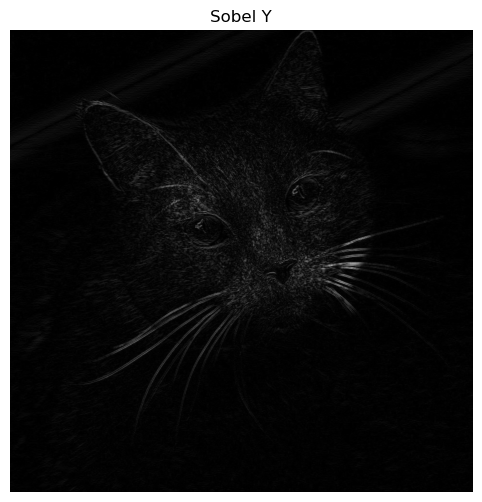

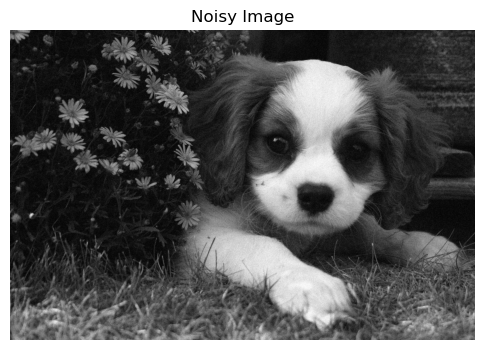

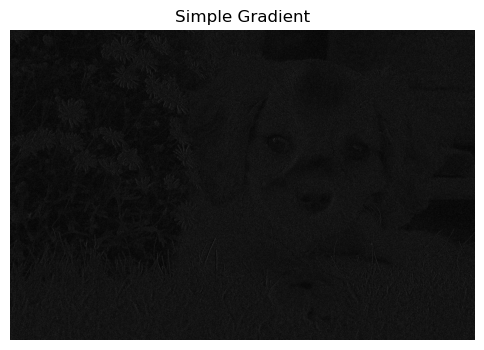

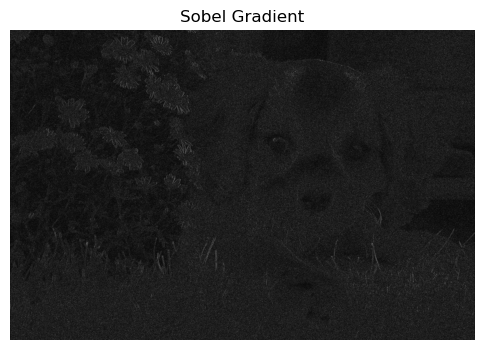

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="image"):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()

sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)


sobelx = cv2.Sobel(step, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(step, cv2.CV_64F, 0, 1, ksize=3)

show(step, "Original Step Image")
show(np.abs(sobelx), "Sobel X")
show(np.abs(sobely), "Sobel Y")

sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)


noise = np.random.normal(0, 25, circle.shape)
noisy = circle + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

show(noisy, "Noisy Image")


kernel_x = np.array([[-1, 1]])

simple_grad = cv2.filter2D(noisy, -1, kernel_x)

show(np.abs(simple_grad), "Simple Gradient")


sobel_noise = cv2.Sobel(noisy, cv2.CV_64F, 1, 0, ksize=3)

show(np.abs(sobel_noise), "Sobel Gradient")




In [17]:
def sobel_edges(image, ksize=3):
    
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)
    
    magnitude = np.sqrt(gx**2 + gy**2)
    
    return gx, gy, magnitude

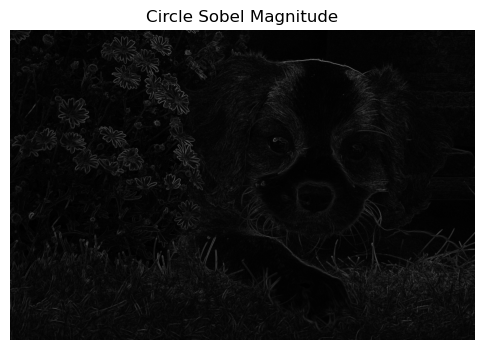

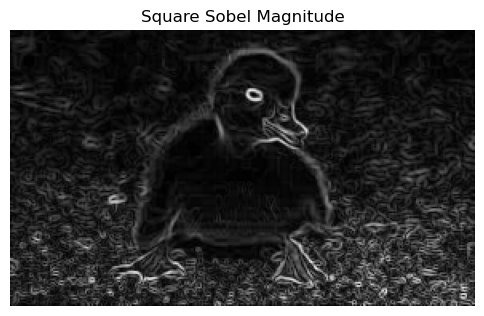

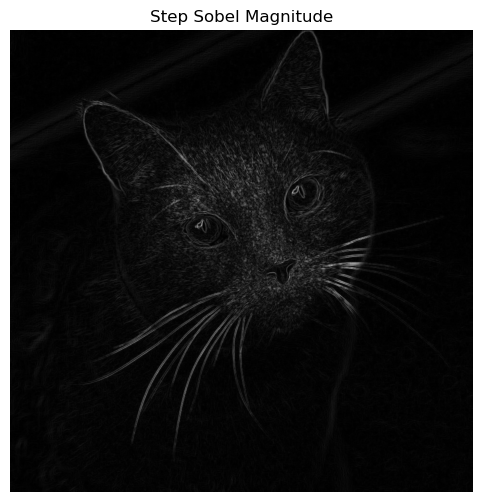

In [20]:
circle = cv2.imread("dog.jpg", 0)
square = cv2.imread("duck.jpg", 0)
step = cv2.imread("cat.jpg", 0)

images = {
    "Circle": circle,
    "Square": square,
    "Step": step
}

results = []

for name, img in images.items():
    
    gx, gy, mag = sobel_edges(img)
    
    show(np.abs(mag), name + " Sobel Magnitude")
    
    strong_edges = np.sum(mag > 50)
    
    results.append((name, strong_edges))

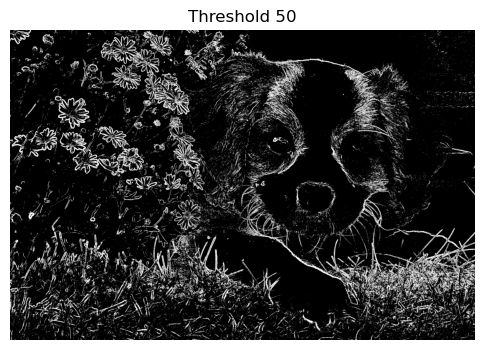

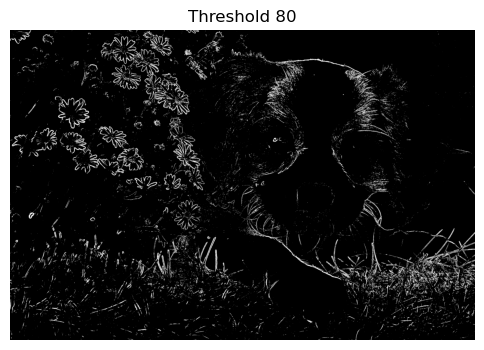

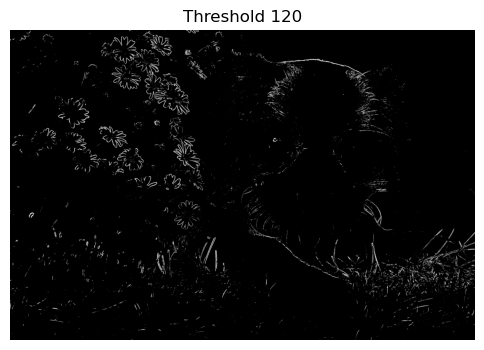

In [21]:
gx, gy, sobel_mag = sobel_edges(circle)

binary_50 = (sobel_mag > 50).astype(np.uint8) * 255
binary_80 = (sobel_mag > 80).astype(np.uint8) * 255
binary_120 = (sobel_mag > 120).astype(np.uint8) * 255

show(binary_50, "Threshold 50")
show(binary_80, "Threshold 80")
show(binary_120, "Threshold 120")